# FL-IENN Framework — Session Layer (Combined Pipeline)
### Datasets: `diabetes_iomt_final.csv` (100,000 records) and `cvd_70k_iomt_final.csv` (70,000 records)

### Module 1: ECC-based Mutual Authentication (Eq. 3.1)
### Module 2: Exponential K-Anonymity — EKA (Eq. 2.2)

Both datasets are run through the **same Session Layer pipeline** (one authentication demo, then EKA applied separately to each dataset), and results are compared side by side at the end.

**Before running:** upload both CSVs and confirm the paths in the cell below.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 1) Install / import dependencies
!pip install cryptography pandas numpy matplotlib --quiet

import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cryptography.hazmat.primitives.asymmetric import ec
from cryptography.hazmat.primitives import hashes
from cryptography.hazmat.primitives.kdf.hkdf import HKDF

pd.set_option("display.width", 140)
np.random.seed(42)


## Step 0: Load both datasets

Update the paths below if needed. The two datasets have slightly different schemas:

| | diabetes_iomt_final.csv | cvd_70k_iomt_final.csv |
|---|---|---|
| age column | `age` | `age_years` (renamed to `age` below) |
| sex values | 0, 1, 2 | 0, 1 |
| health_status | Normal / Moderate / Critical | Normal / Moderate / Critical / **Unknown** |

`Unknown` health_status records in the CVD dataset are **excluded before EKA runs** (per your instruction) — they are not covered by Eq. 2.2's Normal/Moderate/Critical mapping, so they are removed as a separate, explicit step rather than silently guessed at.


In [ ]:
DIABETES_PATH = "/content/drive/MyDrive/Thesis/diabetes_iomt_final.csv"   # <-- update path if needed
CVD_PATH = "/content/drive/MyDrive/Thesis/cvd_70k_iomt_final.csv"          # <-- update path if needed

diabetes_df = pd.read_csv(DIABETES_PATH)
cvd_df = pd.read_csv(CVD_PATH)

# Normalize schema: CVD uses 'age_years' -> rename to 'age' for a unified pipeline
cvd_df = cvd_df.rename(columns={"age_years": "age"})

print(f"diabetes_iomt_final.csv : {diabetes_df.shape[0]} records, {diabetes_df.shape[1]} columns")
print(f"cvd_70k_iomt_final.csv  : {cvd_df.shape[0]} records, {cvd_df.shape[1]} columns")


diabetes_iomt_final.csv : 100000 records, 15 columns
cvd_70k_iomt_final.csv  : 70000 records, 17 columns


In [ ]:
# Explicit exclusion step: CVD 'Unknown' health_status records
cvd_unknown_mask = cvd_df["health_status"] == "Unknown"
n_excluded_unknown = int(cvd_unknown_mask.sum())

cvd_df_clean = cvd_df.loc[~cvd_unknown_mask].copy()

print(f"CVD dataset: excluded {n_excluded_unknown} records with health_status = 'Unknown'")
print(f"CVD dataset: {len(cvd_df_clean)} records remain for the Session Layer pipeline")

print("\ndiabetes health_status distribution:")
print(diabetes_df["health_status"].value_counts())
print("\ncvd (cleaned) health_status distribution:")
print(cvd_df_clean["health_status"].value_counts())


CVD dataset: excluded 1334 records with health_status = 'Unknown'
CVD dataset: 68666 records remain for the Session Layer pipeline

diabetes health_status distribution:
health_status
Moderate    59311
Normal      35003
Critical     5686
Name: count, dtype: int64

cvd (cleaned) health_status distribution:
health_status
Moderate    42535
Critical    18411
Normal       7720
Name: count, dtype: int64


## Module 1: ECC-based Mutual Authentication

Registration credential (**Eq. 3.1**): $R_g = ID_i \parallel PWD_i \parallel k_i$, stored as a SHA-256 hash (never plaintext).
On login, the credential is re-verified, then an **ECDH** key exchange (SECP256R1 curve) establishes a shared session key via HKDF.

This module is device-level (not dataset-specific), so it is demonstrated once — the same authenticated session would apply regardless of which IoMT device/dataset is streaming data.


In [ ]:
class ECCAuthenticator:
    """Device registration + mutual authentication + ECDH session-key establishment."""

    def __init__(self):
        self._device_db = {}
        self.server_private_key = ec.generate_private_key(ec.SECP256R1())
        self.server_public_key = self.server_private_key.public_key()

    def register_device(self, device_id: str, password: str, secret_key_k: str):
        raw = f"{device_id}||{password}||{secret_key_k}".encode()
        R_g_hash = hashlib.sha256(raw).hexdigest()
        device_private_key = ec.generate_private_key(ec.SECP256R1())
        device_public_key = device_private_key.public_key()
        self._device_db[device_id] = {"R_g_hash": R_g_hash, "public_key": device_public_key}
        return device_private_key

    def authenticate(self, device_id, password, secret_key_k, device_private_key):
        log = []
        if device_id not in self._device_db:
            return False, None, ["Device not registered."]
        raw = f"{device_id}||{password}||{secret_key_k}".encode()
        R_g_check = hashlib.sha256(raw).hexdigest()
        log.append(f"Recomputed R_g = SHA256(ID||PWD||k) = {R_g_check[:16]}...")
        if R_g_check != self._device_db[device_id]["R_g_hash"]:
            log.append("Credential mismatch -> AUTH FAILED")
            return False, None, log
        log.append("Credential match -> identity verified")
        shared_secret = device_private_key.exchange(ec.ECDH(), self.server_public_key)
        session_key = HKDF(algorithm=hashes.SHA256(), length=32, salt=None,
                            info=b"fl-ienn-session-layer").derive(shared_secret)
        log.append(f"ECDH shared secret -> session key = {session_key.hex()[:16]}...")
        log.append("AUTH SUCCESS -> device session opened")
        return True, session_key.hex(), log


In [ ]:
# Demo: register a device and authenticate it (shared across both datasets)
auth = ECCAuthenticator()
DEVICE_ID, PASSWORD, SECRET_K = "IOMT-GATEWAY-001", "device-secret-pwd", "k_i_random_9f81"

device_priv_key = auth.register_device(DEVICE_ID, PASSWORD, SECRET_K)
ok, session_key, log = auth.authenticate(DEVICE_ID, PASSWORD, SECRET_K, device_priv_key)
for line in log:
    print(" -", line)
print(f"\nResult: {'SUCCESS' if ok else 'FAILED'}")

ok_bad, _, log_bad = auth.authenticate(DEVICE_ID, "wrong-password", SECRET_K, device_priv_key)
print("\n[Negative test]")
for line in log_bad:
    print(" -", line)
print(f"Result: {'FAILED as expected' if not ok_bad else 'SUCCESS (unexpected!)'}")


 - Recomputed R_g = SHA256(ID||PWD||k) = 55df5b08e7b66a3f...
 - Credential match -> identity verified
 - ECDH shared secret -> session key = 406d56d1dbceb3a3...
 - AUTH SUCCESS -> device session opened

Result: SUCCESS

[Negative test]
 - Recomputed R_g = SHA256(ID||PWD||k) = 0aff39c8cd6d38a9...
 - Credential mismatch -> AUTH FAILED
Result: FAILED as expected


## Module 2: Exponential K-Anonymity (EKA)

**Eq. 2.2:** $CL = tp^{\alpha} \times e^{n}$

- $\alpha$ from `data_sensitivity` (Low = 1, High = 2)
- $n$ from `health_status` (Normal = 1, Moderate = 2, Critical = 3)

Written to work on **any dataset with the standard columns** (`patient_id`, `age`, `sex`, `data_sensitivity`, `health_status`), so the same class runs unchanged on both diabetes and CVD data.


In [ ]:
class ExponentialKAnonymity:
    ALPHA_MAP = {"Low": 1, "High": 2}
    N_MAP = {"Normal": 1, "Moderate": 2, "Critical": 3}

    def __init__(self, tp=2.0, k_min=2, k_max=10, max_gen_level=3):
        self.tp, self.k_min, self.k_max, self.max_gen_level = tp, k_min, k_max, max_gen_level
        self.last_suppressed_count = 0

    def compute_CL(self, sensitivity_label, health_status_label):
        alpha = self.ALPHA_MAP.get(sensitivity_label, 1)
        n = self.N_MAP.get(health_status_label, 1)
        return (self.tp ** alpha) * (np.e ** n), alpha, n

    def _CL_to_k(self, CL, CL_min, CL_max):
        if CL_max == CL_min:
            return self.k_min
        norm = (CL - CL_min) / (CL_max - CL_min)
        return int(round(self.k_min + norm * (self.k_max - self.k_min)))

    @staticmethod
    def _generalize_age(age, level):
        age = int(age)
        if level == 0: return str(age)
        if level == 1:
            lo = (age // 5) * 5; return f"{lo}-{lo+4}"
        if level == 2:
            lo = (age // 10) * 10; return f"{lo}-{lo+9}"
        lo = (age // 20) * 20; return f"{lo}-{lo+19}"

    def anonymize(self, df):
        work = df.copy()
        work["age"] = work["age"].fillna(0).astype(float)
        work[["CL", "alpha", "n"]] = work.apply(
            lambda r: self.compute_CL(r["data_sensitivity"], r["health_status"]),
            axis=1, result_type="expand")
        CL_min, CL_max = work["CL"].min(), work["CL"].max()
        work["k_target"] = work["CL"].apply(lambda cl: self._CL_to_k(cl, CL_min, CL_max))

        out_chunks = []
        for k_target, group in work.groupby("k_target"):
            level = 0
            while level <= self.max_gen_level:
                gen_age = group["age"].apply(lambda a: self._generalize_age(a, level))
                trial = group.copy()
                trial["age_generalized"] = gen_age
                sizes = trial.groupby(["age_generalized", "sex"])["age_generalized"].transform("count")
                if sizes.min() >= k_target or level == self.max_gen_level:
                    trial["k_achieved"] = sizes
                    trial["generalization_level"] = level
                    break
                level += 1
            out_chunks.append(trial)

        result = pd.concat(out_chunks).sort_index()
        suppressed_mask = result["k_achieved"] < result["k_target"]
        self.last_suppressed_count = int(suppressed_mask.sum())
        result = result.loc[~suppressed_mask].copy()
        result = result.drop(columns=["patient_id", "age"]).rename(columns={"age_generalized": "age_anon"})
        return result

    def verify_k_anonymity(self, anon_df):
        violations = anon_df[anon_df["k_achieved"] < anon_df["k_target"]]
        return {
            "total_records": len(anon_df),
            "satisfied_k_anonymity": len(violations) == 0,
            "violating_records": len(violations),
            "avg_generalization_level": round(anon_df["generalization_level"].mean(), 2),
            "avg_k_achieved": round(anon_df["k_achieved"].mean(), 2),
        }


## Step 1: Run the combined pipeline (one function, two datasets)

In [ ]:
def run_session_layer(df, dataset_name, tp=2.0, k_min=2, k_max=10, max_gen_level=3):
    """Runs EKA on one dataset and returns (anonymized_df, report_dict, cl_table)."""

    eka = ExponentialKAnonymity(
        tp=tp,
        k_min=k_min,
        k_max=k_max,
        max_gen_level=max_gen_level
    )

    combo = df[["data_sensitivity", "health_status"]].drop_duplicates()

    combo[["CL", "alpha", "n"]] = combo.apply(
        lambda r: eka.compute_CL(
            r["data_sensitivity"],
            r["health_status"]
        ),
        axis=1,
        result_type="expand"
    )

    combo = combo.sort_values("CL").reset_index(drop=True)

    anon_df = eka.anonymize(df)

    report = eka.verify_k_anonymity(anon_df)
    report["dataset"] = dataset_name
    report["input_records"] = len(df)
    report["released_records"] = len(anon_df)
    report["suppressed_records"] = eka.last_suppressed_count

    print(f"=== {dataset_name} ===")
    print(f"Input:     {report['input_records']}")
    print(f"Released:  {report['released_records']}")
    print(f"Suppressed:{report['suppressed_records']:>6}")
    print(f"k-anonymity satisfied: {report['satisfied_k_anonymity']}\n")

    return anon_df, report, combo

In [ ]:
diabetes_anon, diabetes_report, diabetes_cl = run_session_layer(diabetes_df, "diabetes_iomt_final")
cvd_anon, cvd_report, cvd_cl = run_session_layer(cvd_df_clean, "cvd_70k_iomt_final (Unknown excluded)")

# Note: CVD's total exclusions = Unknown-status exclusion (n_excluded_unknown) + any k-anonymity suppression
cvd_report["excluded_unknown_status"] = n_excluded_unknown


=== diabetes_iomt_final ===
Input:     100000
Released:  99987
Suppressed:    13
k-anonymity satisfied: True

=== cvd_70k_iomt_final (Unknown excluded) ===
Input:     68666
Released:  68666
Suppressed:     0
k-anonymity satisfied: True



In [ ]:
# --- diabetes sample table ---
print(f"Input records:    {diabetes_report['input_records']}")
print(f"Released records: {diabetes_report['released_records']}")
print(f"Suppressed:       {diabetes_report['suppressed_records']}")

diabetes_anon[["age_anon", "sex", "data_sensitivity", "health_status",
               "CL", "k_target", "generalization_level", "k_achieved"]].head(10)

Input records:    100000
Released records: 99987
Suppressed:       13


,age_anon,sex,data_sensitivity,health_status,CL,k_target,generalization_level,k_achieved
0,80-99,0,High,Moderate,29.556224,5,3,1969
1,40-59,0,High,Moderate,29.556224,5,3,10313
2,20-39,1,High,Moderate,29.556224,5,3,5605
3,20-39,0,Low,Normal,5.436564,2,3,6258
4,60-79,1,Low,Normal,5.436564,2,3,2426
...,...,...,...,...,...,...,...,...
99995,80-99,0,High,Moderate,29.556224,5,3,1969
99996,0-19,0,High,Moderate,29.556224,5,3,6094
99997,60-79,1,High,Moderate,29.556224,5,3,4642
99998,20-39,0,Low,Normal,5.436564,2,3,6258


In [ ]:
# --- cvd sample table ---
print(f"Input records (after excluding Unknown): {len(cvd_df_clean)}")
print(f"Released records: {cvd_report['released_records']}")
print(f"Suppressed:       {cvd_report['suppressed_records']}")
print(f"Excluded (Unknown health_status, before EKA): {n_excluded_unknown}")

cvd_anon[["age_anon", "sex", "data_sensitivity", "health_status",
          "CL", "k_target", "generalization_level", "k_achieved"]].head(10)

Input records (after excluding Unknown): 68666
Released records: 68666
Suppressed:       0
Excluded (Unknown health_status, before EKA): 1334


,age_anon,sex,data_sensitivity,health_status,CL,k_target,generalization_level,k_achieved
0,40-59,1,High,Moderate,29.556224,5,3,11908
1,55,0,High,Critical,80.342148,10,0,781
2,40-59,0,High,Moderate,29.556224,5,3,22127
3,48,1,High,Critical,80.342148,10,0,167
4,40-59,0,Low,Normal,5.436564,2,3,4833
5,40-59,0,High,Moderate,29.556224,5,3,22127
6,60-79,0,High,Moderate,29.556224,5,3,4752
7,61,1,High,Critical,80.342148,10,0,405
8,40-59,0,Low,Normal,5.436564,2,3,4833
9,40-59,0,Low,Normal,5.436564,2,3,4833


## Step 2: Combined summary — side by side

In [ ]:
summary = pd.DataFrame([
    {
        "Dataset": "diabetes_iomt_final",
        "Input records": diabetes_report["input_records"],
        "Excluded (Unknown status)": 0,
        "Suppressed (k-anonymity)": diabetes_report["suppressed_records"],
        "Released records": diabetes_report["released_records"],
        "k-anonymity satisfied": diabetes_report["satisfied_k_anonymity"],
        "Avg generalization level": diabetes_report["avg_generalization_level"],
    },
    {
        "Dataset": "cvd_70k_iomt_final",
        "Input records": len(cvd_df),
        "Excluded (Unknown status)": n_excluded_unknown,
        "Suppressed (k-anonymity)": cvd_report["suppressed_records"],
        "Released records": cvd_report["released_records"],
        "k-anonymity satisfied": cvd_report["satisfied_k_anonymity"],
        "Avg generalization level": cvd_report["avg_generalization_level"],
    },
])
summary


,Dataset,Input records,Excluded (Unknown status),Suppressed (k-anonymity),Released records,k-anonymity satisfied,Avg generalization level
0,diabetes_iomt_final,100000,0,13,99987,True,3.0
1,cvd_70k_iomt_final,70000,1334,0,68666,True,2.2


In [ ]:
print("CL table — diabetes_iomt_final:")
print(diabetes_cl.to_string(index=False))
print("\nCL table — cvd_70k_iomt_final:")
print(cvd_cl.to_string(index=False))


CL table — diabetes_iomt_final:
data_sensitivity health_status        CL  alpha   n
             Low        Normal  5.436564    1.0 1.0
            High      Moderate 29.556224    2.0 2.0
            High      Critical 80.342148    2.0 3.0

CL table — cvd_70k_iomt_final:
data_sensitivity health_status        CL  alpha   n
             Low        Normal  5.436564    1.0 1.0
            High      Moderate 29.556224    2.0 2.0
            High      Critical 80.342148    2.0 3.0


## Step 3: Visualize (for supervisor presentation)

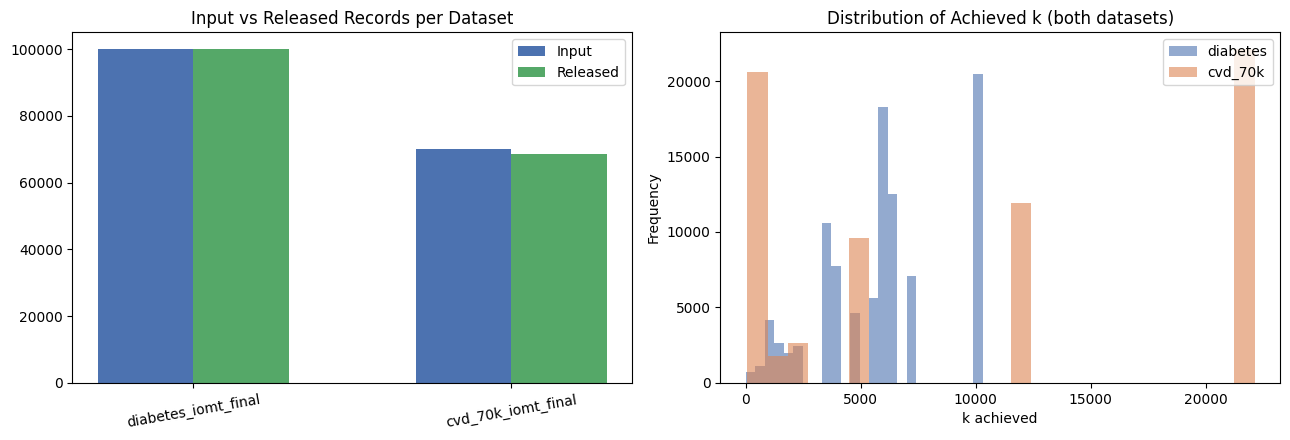

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

x = np.arange(len(summary))
width = 0.3
axes[0].bar(x - width/2, summary["Input records"], width, label="Input", color="#4C72B0")
axes[0].bar(x + width/2, summary["Released records"], width, label="Released", color="#55A868")
axes[0].set_xticks(x); axes[0].set_xticklabels(summary["Dataset"], rotation=10)
axes[0].set_title("Input vs Released Records per Dataset")
axes[0].legend()

diabetes_anon["k_achieved"].plot(kind="hist", bins=25, ax=axes[1], alpha=0.6, label="diabetes", color="#4C72B0")
cvd_anon["k_achieved"].plot(kind="hist", bins=25, ax=axes[1], alpha=0.6, label="cvd_70k", color="#DD8452")
axes[1].set_title("Distribution of Achieved k (both datasets)")
axes[1].set_xlabel("k achieved")
axes[1].legend()

plt.tight_layout()
plt.savefig("session_layer_combined_results.png", dpi=150)
plt.show()


## Step 4: Save outputs

In [ ]:
diabetes_anon.to_csv("diabetes_session_layer_anonymized.csv", index=False)
cvd_anon.to_csv("cvd_session_layer_anonymized.csv", index=False)
summary.to_csv("session_layer_combined_summary.csv", index=False)

with open("session_layer_combined_report.txt", "w") as f:
    f.write("SESSION LAYER — COMBINED RESULT SUMMARY\n")
    f.write("=" * 50 + "\n\n")
    f.write("MODULE 1: ECC-based Mutual Authentication\n")
    f.write(f"  Authentication (correct credentials): {'SUCCESS' if ok else 'FAILED'}\n")
    f.write(f"  Authentication (wrong credentials): {'FAILED as expected' if not ok_bad else 'SUCCESS (BUG!)'}\n\n")
    f.write("MODULE 2: Exponential K-Anonymity — per dataset\n\n")
    f.write(summary.to_string(index=False) + "\n\n")
    f.write("CL table — diabetes_iomt_final:\n")
    f.write(diabetes_cl.to_string(index=False) + "\n\n")
    f.write("CL table — cvd_70k_iomt_final:\n")
    f.write(cvd_cl.to_string(index=False) + "\n")

print("Saved: diabetes_session_layer_anonymized.csv, cvd_session_layer_anonymized.csv,")
print("       session_layer_combined_summary.csv, session_layer_combined_report.txt,")
print("       session_layer_combined_results.png")


Saved: diabetes_session_layer_anonymized.csv, cvd_session_layer_anonymized.csv,
       session_layer_combined_summary.csv, session_layer_combined_report.txt,
       session_layer_combined_results.png


## Next step

Both anonymized datasets (`diabetes_anon`, `cvd_anon`) are now ready to be forwarded to the **Privacy & Security Layer** — Federated Learning + IENN classification (data sensitivity and health-status prediction) — the same way the PTB-XL output was.
